### Step 0: Neccessary imports

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gammaln

### Step 1: Generate Logrithmic Data

This step involves generating log-spaced data.  

$r_n = r_0 \cdot e^{\frac{nL}{N}}$ 

$r_0$ is the initial value of log-spaced data

$n$ is an array of indices 

$L$ is the length of the interval in log-space

$N$ is the number of points generated

Then we add gaussian noise to the data - sigma and the scaling factor determine the amount of noise added to the data. sigma is std deviation of the noise which is set at 10, we have set our scaling factor to be 500 to see the effects of noise on the generated data

Lastly, we plot the generated data and the noisy data. 

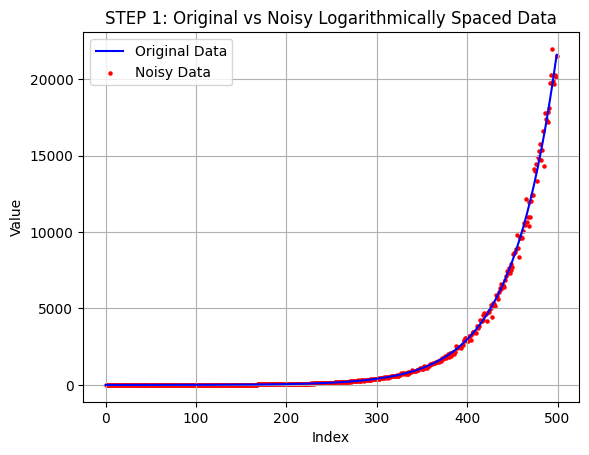

In [3]:
# Step 1a: Generate Logarithmic Data
def generate_log_data(r0, L, N):
    """
    Generate logarithmically spaced data points.
    :param r0: Initial value.
    :param L: Logarithmic range.
    :param N: Number of points.
    :return: Logarithmically spaced data points.
    """
    n = np.arange(N)             # Indices
    r = r0 * np.exp(n * L / N)   # Log spaced points
    return r

# Step 1b: Add noise to the data
def add_noise(log_data, sigma, scale=1000):
    """
    Add Gaussian noise to the data, scaled to the magnitude of the data.
    :param log_data: Logarithmically spaced points.
    :param sigma: Standard deviation of the noise.
    :param scale_factor: Scaling factor for the noise.
    :return: Logarithmically spaced points with noise.
    """
    np.random.seed(0)
    noise = np.random.normal(0, sigma, len(log_data))
    # Scale the noise relative to the magnitude of the data
    log_data_noisy = log_data + noise * log_data / np.max(log_data) * scale
    return log_data_noisy

# Generate data
r0, L, N = 1, 10.0, 500
log_data = generate_log_data(r0, L, N)
sigma = 1
log_data_noisy = add_noise(log_data, sigma)

# Plot the original and noisy data
# plt.figure(figsize=(10, 6))
plt.plot(log_data, 'b-', label='Original Data')
plt.scatter(np.arange(N), log_data_noisy, color='r', s=5, label='Noisy Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('STEP 1: Original vs Noisy Logarithmically Spaced Data')
plt.legend()
plt.grid()
plt.show()

### Step 2: Forward Discrete Fourier Transform (DFT) and Inverse DFT
The Fourier Transform decomposes a function  a(r)  into a sum of complex exponentials (sine and cosine waves) with varying frequencies. Mathematically, this is expressed as:

$\tilde{a}(k) = \int_{-\infty}^{\infty} a(r) e^{-i 2 \pi k r} dr$

$a(r)$ is periodic in logarithmic space $ln(r)$ 

We are dealing with discrete log-spaced points

DFT: For  N  discrete logarithmic points, the Fourier transform of  $a(r)$  is:

$\tilde{a}m = \frac{1}{N} \sum{n=0}^{N-1} a_n e^{-2\pi i m n / N}$

The FFT (Fast Fourier Transform) is a computationally efficient algorithm to calculate the DFT.

Inverse DFT is used to reconstruct the signal given the fourier coefficients, we do this as a sanity check. 

Fourier Coefficients (first 10): [ 2.49387570e+03  +0.j         -4.04484488e+00+794.65265334j
 -5.08147620e+00+397.93655256j -4.86997863e+00+266.65473248j
 -3.84247656e+00+199.04823437j -2.47930021e+00+158.24079013j
 -4.89484107e+00+131.51683666j -3.73246069e+00+113.46842311j
 -5.85866983e+00 +99.61081496j -5.00983105e+00 +88.35823628j]


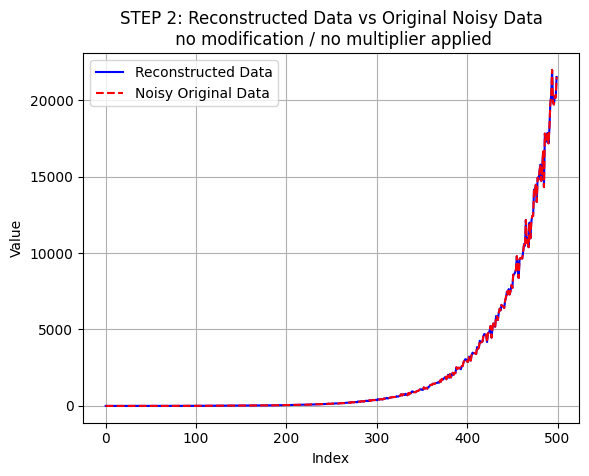

Reconstructed Data (5): ['1.082', '1.039', '1.088', '1.172', '1.177']
Original Noisy Data (5): ['1.082', '1.039', '1.088', '1.172', '1.177']


In [41]:
# Step 2a: Logarithmic Transformation
log_data_noisy_log = np.log(log_data_noisy + 1e-10)  # Add a small constant to avoid log(0)

# Check for nan values after logarithmic transformation
# print("NaN values after log transformation:", np.isnan(log_data_noisy_log).sum())

# Step 2b: Resampling to ensure evenly spaced data in the logarithmic domain
resampled_indices = np.linspace(0, N-1, N)
resampled_log_data_noisy_log = np.interp(resampled_indices, np.arange(N), log_data_noisy_log)

# Check for nan values after resampling
# print("NaN values after resampling:", np.isnan(resampled_log_data_noisy_log).sum())

# Step 2c: Perform the Fourier Transform on the resampled data - ORIGINAL FOURIER VALUES
fourier_coefficients = np.fft.fft(resampled_log_data_noisy_log)

# Step 2d: Print first 10 Fourier coefficients
print("Fourier Coefficients (first 10):", fourier_coefficients[:10])

# Step 2e: Modify the Fourier Coefficients (if necessary)
# For this example, we will not modify the coefficients
fc_no_mod = fourier_coefficients

# Step 2g: Perform the inverse FFT
reconst_log_data_no_mod = np.fft.ifft(fc_no_mod)

# Check for nan values after inverse FFT
# print("NaN values after inverse FFT:", np.isnan(reconst_log_data_no_mod).sum())

# Step 2h: Exponentiate to revert the logarithmic transformation
reconst_data_no_mod = np.exp(np.real(reconst_log_data_no_mod))

# Handle nan values in the reconstructed data
reconst_data_no_mod = np.nan_to_num(reconst_data_no_mod, nan=0.0)

# Step 2i: Plot the reconstructed data against the original noisy data
# plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(log_data_noisy)), reconst_data_no_mod, 'b-', label='Reconstructed Data')
plt.plot(np.arange(len(log_data_noisy)), log_data_noisy, 'r--', label='Noisy Original Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('STEP 2: Reconstructed Data vs Original Noisy Data\n no modification / no multiplier applied')
plt.legend()
plt.grid()
plt.show()

# Step 2j: Inspect the first 5 reconstructed values, only 2 floating point values are shown
print("Reconstructed Data (5):", [f"{x:.3f}" for x in reconst_data_no_mod[:5]])
print("Original Noisy Data (5):", [f"{x:.3f}" for x in log_data_noisy[:5]])

##### The Fourier coefficients from Step 2 (fourier_coefficients) are directly used for the inverse FFT without any changes.
##### The reconstruction is based purely on the noisy data, with no consideration of theoretical properties or bias correction that  $u_m$ (multiplier function) might introduce.

### Step 3: Multiplier function
This step involves computing the multiplier function $u_m$ , a critical component of the FFTLog algorithm. This function incorporates properties of Bessel functions and Gamma functions, and it is used to modify the Fourier coefficients for efficient computation of Hankel transforms.

The multiplier $u_m$ adjusts the Fourier coefficients in logarithmic space to compute the Hankel transform in a discrete setting. It effectively encodes the behavior of the Bessel function  $J_\nu(x)$ in Fourier space and accounts for the log-space data set.

This function is used to transform data between logarithmically spaced input space and Fourier space.

The formula for $u_m$  is: $u_m(\nu, q) = (k_0 r_0)^{-2\pi i m / L} \cdot U_\nu \left(q + \frac{2\pi i m}{L}\right)$

$k_0$  and  $r_0$ : Central values in Fourier and input spaces, respectively.

$L$ : Logarithmic length of the interval.

$\nu$ : Order of the Bessel function.

$q$ : Power-law bias parameter.

$U_\nu(x)$ : A function involving the Gamma function, defined as:

$U_\nu(x) = \int_0^\infty t^x J_\nu(t) dt = 2 \cdot x^{-\nu} \cdot \frac{\Gamma\left(\frac{\nu+1+x}{2}\right)}{\Gamma\left(\frac{\nu+1-x}{2}\right)}$

$\Gamma(z)$ : the Gamma function.

$J_\nu(x)$ : the Bessel function



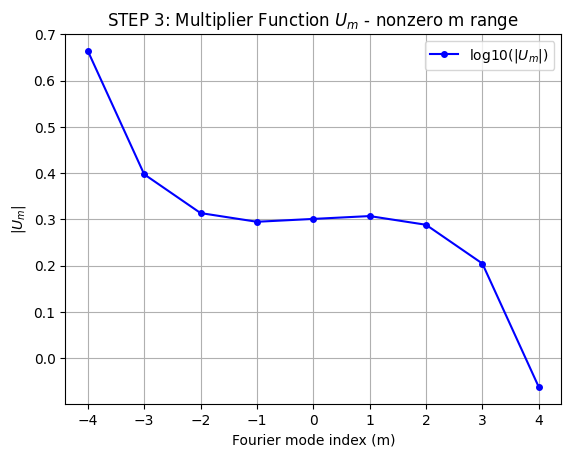

In [9]:
def calculate_multiplier(k0, r0, L, m, nu, q, N):
    """
    Compute the multiplier function u_m for FFTLog.
    :k0: Central value in Fourier space.
    :r0: Central value in input space.
    :L: Logarithmic interval length.
    :m: Fourier mode index.
    :nu: Order of the Bessel function.
    :q: Bias parameter.
    :N: Number of points.
    :return: Multiplier function u_m.
    """
    # Complex argument for U_nu
    im = 2 * np.pi * m / L
    x = q + im

    # Handle invalid x values
    if np.abs(im) > 10 or np.real(nu + 1 + x) <= 0 or np.real(nu + 1 - x) <= 0:
        return 0.0

    # Compute log(U_nu) for numerical stability
    log_U_nu = (
        np.log(2) +
        gammaln((nu + 1 + x) / 2) -
        gammaln((nu + 1 - x) / 2)
    )
    U_nu = np.exp(log_U_nu)

    # Combine with the exponential factor
    u_m = (k0 * r0)**(-im) * U_nu

    return u_m

# Example usage
k0, r0, L, nu, q, N = 1.0, 1.0, 10.0, 2, 0.0, 500
m_values = np.arange(-N//2, N//2)  # Fourier mode indices
u_m_values = np.array([calculate_multiplier(k0, r0, L, m, nu, q, N) for m in m_values])

# Step 3e: Detect non-zero indices and apply them to m and u_m
non_zero_indices = np.where(u_m_values != 0)[0]    # Indices where u_m is non-zero
m_values_nonzero = m_values[non_zero_indices]      # Restrict m values to non-zero range
u_m_values_nonzero = u_m_values[non_zero_indices]  # Restrict u_m values to non-zero range

# Step 3f: convert u_m values to log scale
log_u_m_values = np.log10(np.abs(u_m_values_nonzero) + 1e-10)

# Step 3g: Plot the multiplier function u_m
plt.plot(m_values_nonzero, np.log10(np.abs(u_m_values_nonzero)), 'bo-', markersize = 4, label='log10($|U_m|$)')
plt.xlabel('Fourier mode index (m)')
plt.ylabel('$|U_m|$')
plt.title('STEP 3: Multiplier Function $U_m$ - nonzero m range')
plt.legend()
plt.grid()
plt.show()

### Step 4: Applying the Multiplier to Fourier Coefficients

This step involves modifying the Fourier coefficients  $\tilde{a}_m$  by multiplying them with the multiplier function  u_m . This step transforms the Fourier coefficients in a way that incorporates the logarithmic space and the Hankel transform properties.

The transformation is mathematically expressed as:

$\tilde{a}_m \to \tilde{a}_m u_m$

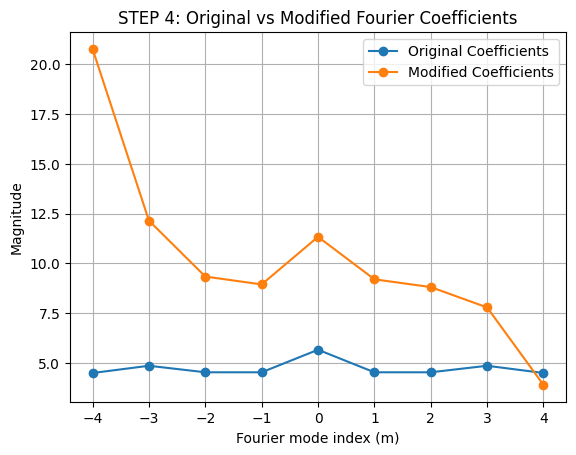

(9,)
(9,)
(9,)
(9,)
(9,)
(500,)


In [10]:
# Step 4a: Apply the multiplier to Fourier coefficients
def apply_multiplier(fc_nonzero, u_m_values_nonzero):
    """
    Apply the multiplier to the valid Fourier coefficients.
    :param fourier_coefficients_nonzero: Fourier coefficients for non-zero m range.
    :param u_m_values_nonzero: Multiplier function values for non-zero m range.
    :return: Modified Fourier coefficients.
    """
    multiplier = fc_nonzero * u_m_values_nonzero
    return multiplier

# Step 4b: Extract the Fourier coefficients for the non-zero m range
fc_nonzero = fourier_coefficients[non_zero_indices]  # Extract valid Fourier coefficients

# Step 4c: Apply the multiplier
fc_mod_coeff = apply_multiplier(fc_nonzero, u_m_values_nonzero)

# Plot original coefficients
plt.plot(m_values_nonzero, np.abs(fc_nonzero), 'o-', label='Original Coefficients')

# Plot modified coefficients
plt.plot(m_values_nonzero, np.abs(fc_mod_coeff), 'o-', label='Modified Coefficients')

# Add labels, title, and legend
plt.xlabel('Fourier mode index (m)')
plt.ylabel('Magnitude')
plt.title('STEP 4: Original vs Modified Fourier Coefficients')
plt.legend()
plt.grid()
plt.show()

print(fc_mod_coeff.shape)
print(non_zero_indices.shape)
print(m_values_nonzero.shape)
print(u_m_values_nonzero.shape)
print(fc_nonzero.shape)
print(fourier_coefficients.shape)


The scaling at low m, and the damping at high m is as expected. The plot looks correct.

### Step 5: Inverse FFT - Reconstructing the modified data

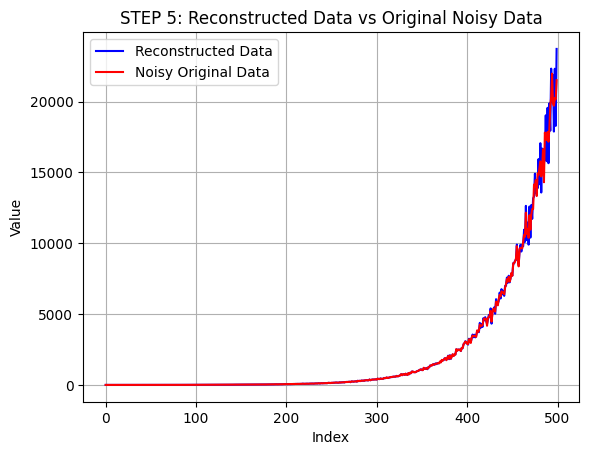

In [12]:
# STEP 5a: Make a new array full_mod_coeff that is a copy of fourier_coefficients - so that there is no loss of information.
# Replace the values at the non-zero indices with the modified coefficients
full_mod_coeff = fourier_coefficients.copy()
full_mod_coeff[non_zero_indices] = fc_mod_coeff

# Step 5b: Perform the inverse FFT
reconst_log_data = np.fft.ifft(full_mod_coeff)

# Step 5c: Exponentiate the result to revert the logarithmic transformation
reconst_data_modified = np.exp(np.real(reconst_log_data))

# Step 5d: Plot the result
# plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(log_data_noisy)), reconst_data_modified, 'b-', label='Reconstructed Data')
plt.plot(np.arange(len(log_data_noisy)), log_data_noisy, 'r-', label='Noisy Original Data')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('STEP 5: Reconstructed Data vs Original Noisy Data')
plt.legend()
plt.grid()
plt.show()

##### In step 5 we see reconstruction after a multiplier $u_m$  is applied to the Fourier coefficients before performing the inverse FFT.
##### The multiplier  $u_m$  is derived from the FFTLog framework and incorporates logarithmic spacing and theoretical considerations. It depends on parameters like  $L$ ,  $r_0$ ,  $k_0$ , and  $\nu$ 

In [42]:
import random
import numpy as np

# Convert to lists
reconst_data_modified_list = list(reconst_data_modified)
log_data_noisy_list = list(log_data_noisy)

# Get 10 random indices from the reconstructed data
random_indices = random.sample(range(len(reconst_data_modified_list)), 5)

# Print the 10 random values from the reconstructed data as an array
random_reconstructed = np.array([reconst_data_modified_list[i] for i in random_indices])
print("Random 5 values from reconstructed data:", [f"{x:.3f}" for x in random_reconstructed])

# Print the values from the original data at the same indices as an array
random_original = np.array([log_data_noisy_list[i] for i in random_indices])
print("Original noisy data at the same indices:", [f"{x:.3f}" for x in random_original])

Random 5 values from reconstructed data: ['232.927', '4034.185', '100.068', '221.598', '19962.422']
Original noisy data at the same indices: ['235.385', '4151.446', '100.941', '225.499', '21975.367']


### Step 6: Compare all data

Mean Absolute Error (MAE): 0.60%
Root Mean Square Error (RMSE): 1.93%


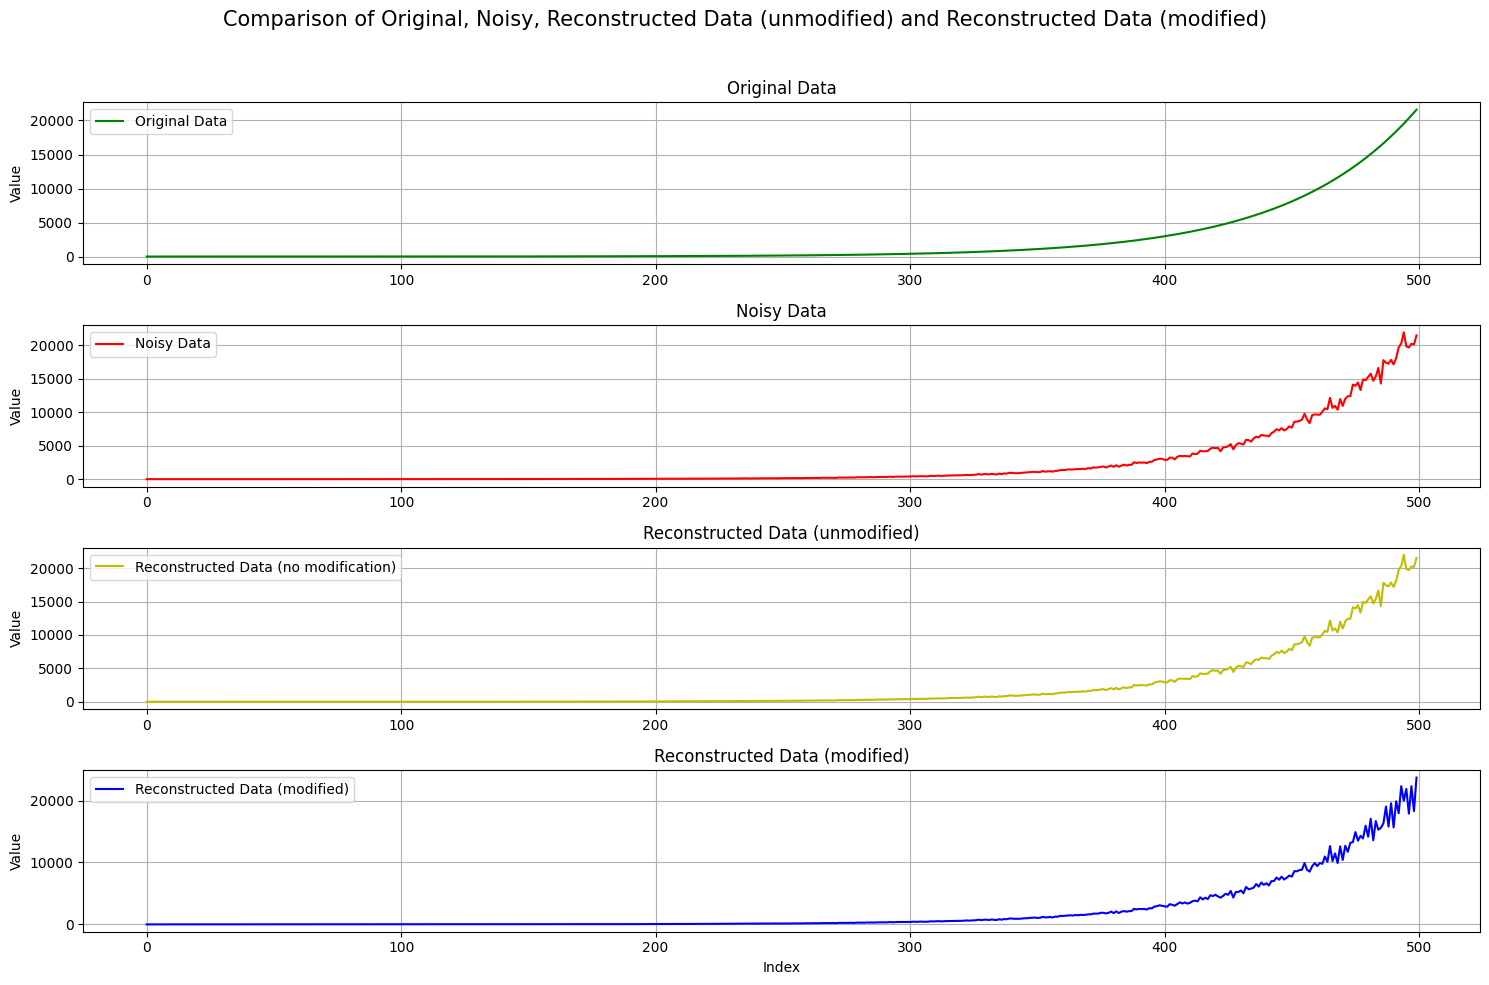

In [44]:
# Step 6b: Calculate the error metrics in percentage

mae = np.mean(np.abs(reconst_data_modified - log_data))
rmse = np.sqrt(np.mean((reconst_data_modified - log_data)**2))
max_value = np.max(log_data)
mae_percentage = (mae / max_value) * 100
rmse_percentage = (rmse / max_value) * 100

print(f"Mean Absolute Error (MAE): {mae_percentage:.2f}%")
print(f"Root Mean Square Error (RMSE): {rmse_percentage:.2f}%")

# Step 6c: Plot comparisons side by side
fig, axs = plt.subplots(4, 1, figsize=(15, 10))
# Add a title for the entire figure
fig.suptitle('Comparison of Original, Noisy, Reconstructed Data (unmodified) and Reconstructed Data (modified)', fontsize=15)

# Plot 1: Original Data
axs[0].plot(log_data, 'g-', markersize=3, label='Original Data')
axs[0].set_ylabel('Value')
axs[0].set_title('Original Data')
axs[0].legend()
axs[0].grid()

# Plot 2: Noisy Data
axs[1].plot(log_data_noisy, 'r-', label='Noisy Data')
axs[1].set_ylabel('Value')
axs[1].set_title('Noisy Data')
axs[1].legend()
axs[1].grid()

# Plot 3: Reconstructed Data
axs[2].plot(reconst_data_no_mod, 'y-', label='Reconstructed Data (no modification)')
axs[2].set_ylabel('Value')
axs[2].set_title('Reconstructed Data (unmodified)')
axs[2].legend()
axs[2].grid()

# Plot 4: Reconstructed Data (Modified)
axs[3].plot(reconst_data_modified, 'b-', label='Reconstructed Data (modified)')
axs[3].set_ylabel('Value')
axs[3].set_xlabel('Index')
axs[3].set_title('Reconstructed Data (modified)')
axs[3].legend()
axs[3].grid()

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the title
plt.show()

# Save the figure
fig.savefig('/Users/ish/Downloads/comparison_plot_FFTLog.png')